2.1 Introduction to Python Imaging Library(PIL)

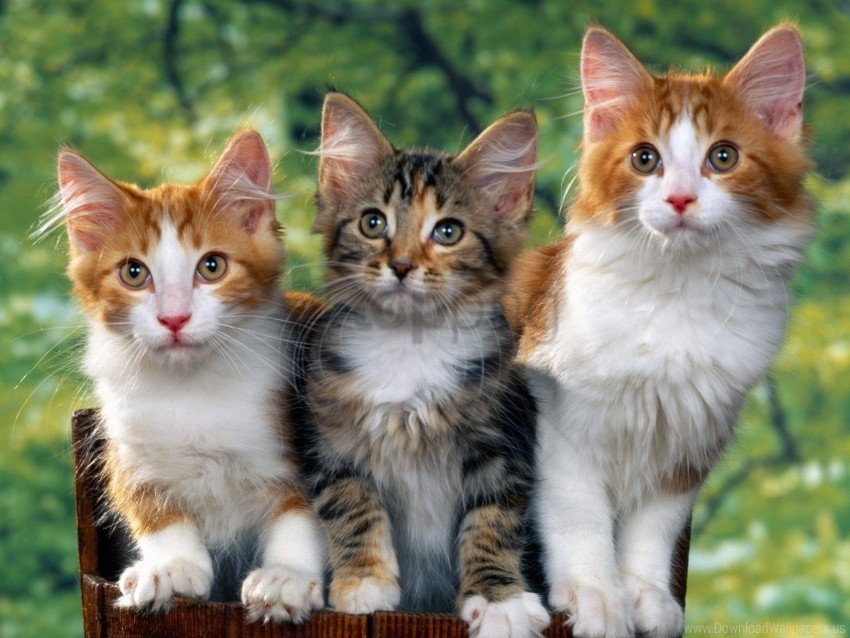

In [ ]:
#task 1
from PIL import Image
image_colored = Image . open ("/content/drive/MyDrive/AI and ML/cats.jpg")
display ( image_colored )

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

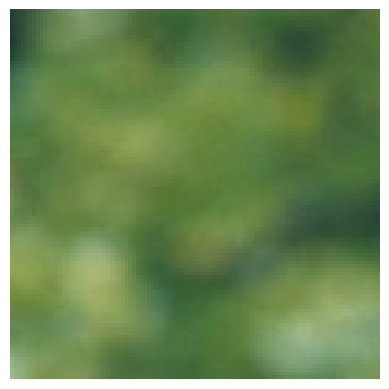

In [ ]:
#task 2
image_array = np.array(image_colored)

top_left = image_array[:100, :100]
plt.imshow(top_left)
plt.axis('off')
plt.show()

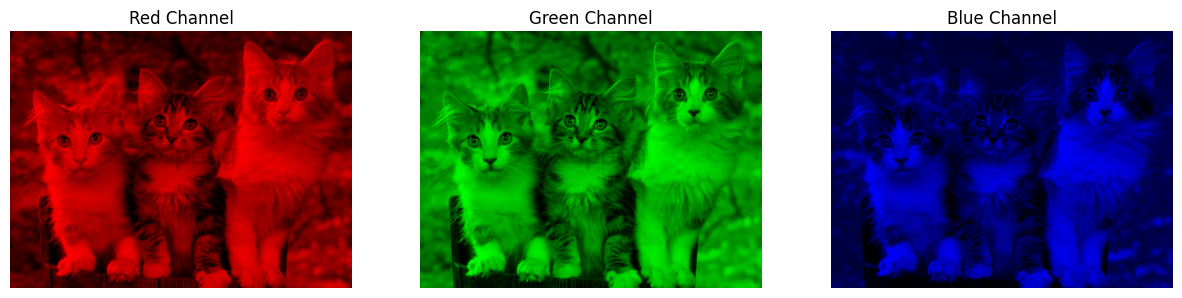

In [ ]:
#task 3
image_array = np.array(image_colored)

R = image_array.copy()
R[:, :, 1] = 0
R[:, :, 2] = 0

G = image_array.copy()
G[:, :, 0] = 0
G[:, :, 2] = 0

B = image_array.copy()
B[:, :, 0] = 0
B[:, :, 1] = 0
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(R)
axs[0].set_title('Red Channel')
axs[0].axis('off')

axs[1].imshow(G)
axs[1].set_title('Green Channel')
axs[1].axis('off')

axs[2].imshow(B)
axs[2].set_title('Blue Channel')
axs[2].axis('off')

plt.show()

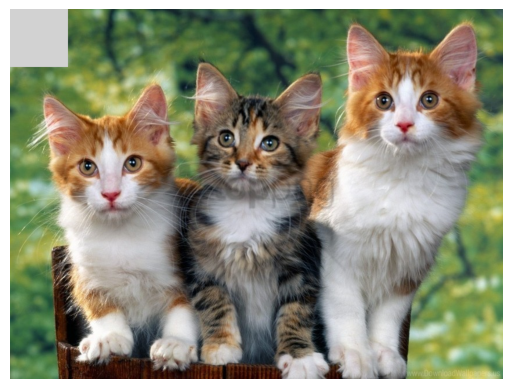

In [ ]:
#task 4
image_array = np.array(image_colored)
image_array[:100, :100, :] = 210

modified_image = Image.fromarray(image_array)

plt.imshow(modified_image)
plt.axis('off')
plt.show()

2.2 Exercise - 2:

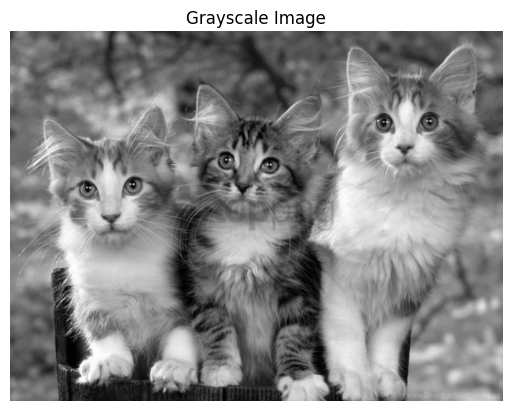

In [ ]:
#task 1
grayscale_image = Image.open("/content/drive/MyDrive/AI and ML/cats.jpg").convert('L')

plt.imshow(grayscale_image, cmap='gray')
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

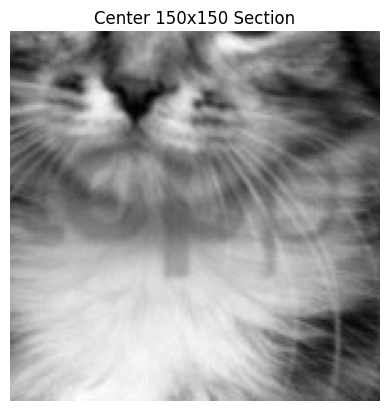

In [ ]:
#task 2
image_array = np.array(grayscale_image)

height, width = image_array.shape

center_y = height // 2
center_x = width // 2
half_size = 150 // 2
center_crop = image_array[center_y - half_size:center_y + half_size,
                          center_x - half_size:center_x + half_size]

plt.imshow(center_crop, cmap='gray')
plt.axis('off')
plt.title("Center 150x150 Section")
plt.show()

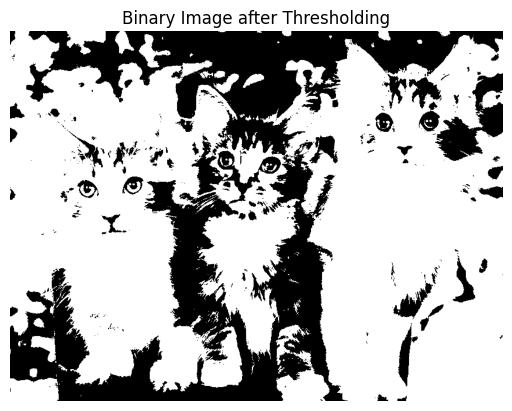

In [ ]:
#task 3
image_array = np.array(grayscale_image)
binary_image = np.where(image_array < 100, 0, 255).astype(np.uint8)

binary_image_pil = Image.fromarray(binary_image)

plt.imshow(binary_image_pil, cmap='gray')
plt.axis('off')
plt.title("Binary Image after Thresholding")
plt.show()

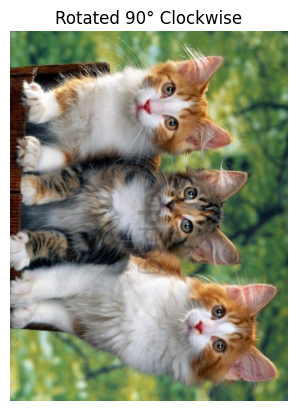

In [ ]:
#task 4
rotated_image = image.rotate(-90, expand=True)

plt.imshow(rotated_image)
plt.axis('off')
plt.title("Rotated 90° Clockwise")
plt.show()

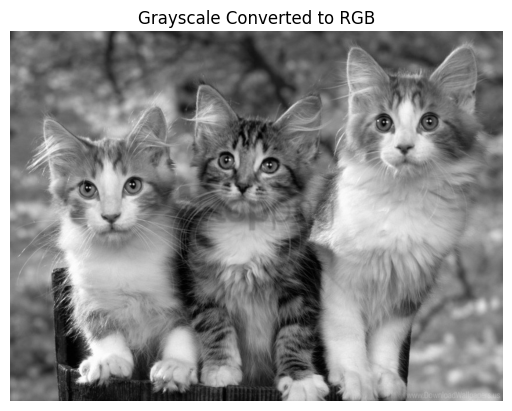

In [ ]:
#task 5
gray_array = np.array(grayscale_image)
rgb_array = np.stack((gray_array,)*3, axis=-1)
rgb_image = Image.fromarray(rgb_array)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Grayscale Converted to RGB")
plt.show()

3 Image Compression and Decompression using PCA.

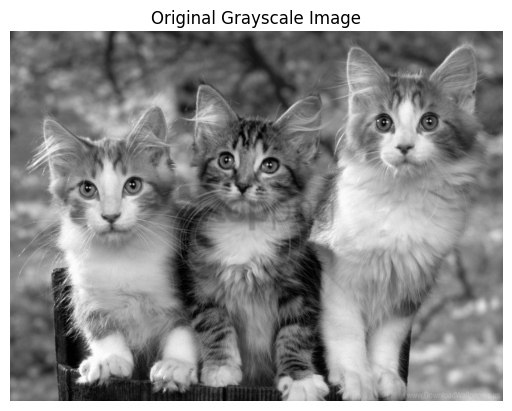

Covariance matrix shape: (850, 850)


In [ ]:
#task 1
image = Image.open("/content/drive/MyDrive/AI and ML/cats.jpg").convert('L')

image_array = np.array(image, dtype=np.float64)
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.title("Original Grayscale Image")
plt.show()

X = image_array.copy()
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

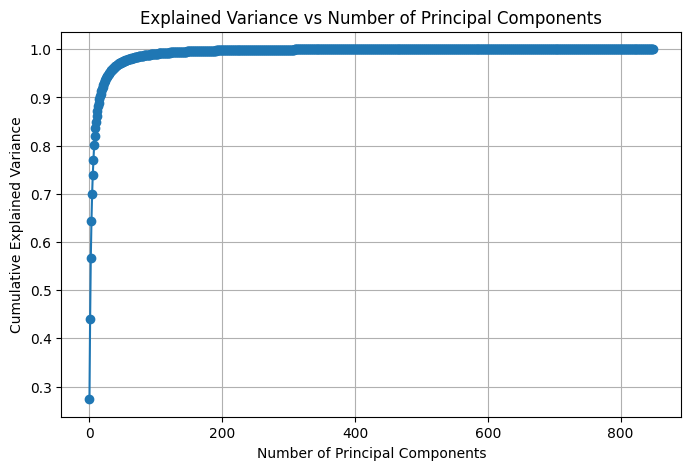

In [ ]:
#task 2
image_array = np.array(image, dtype=np.float64)

X = image_array.copy()
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

cov_matrix = np.cov(X_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Principal Components")
plt.grid(True)
plt.show()

Shape of compressed data: (638, 50)
Shape of decompressed data: (638, 850)


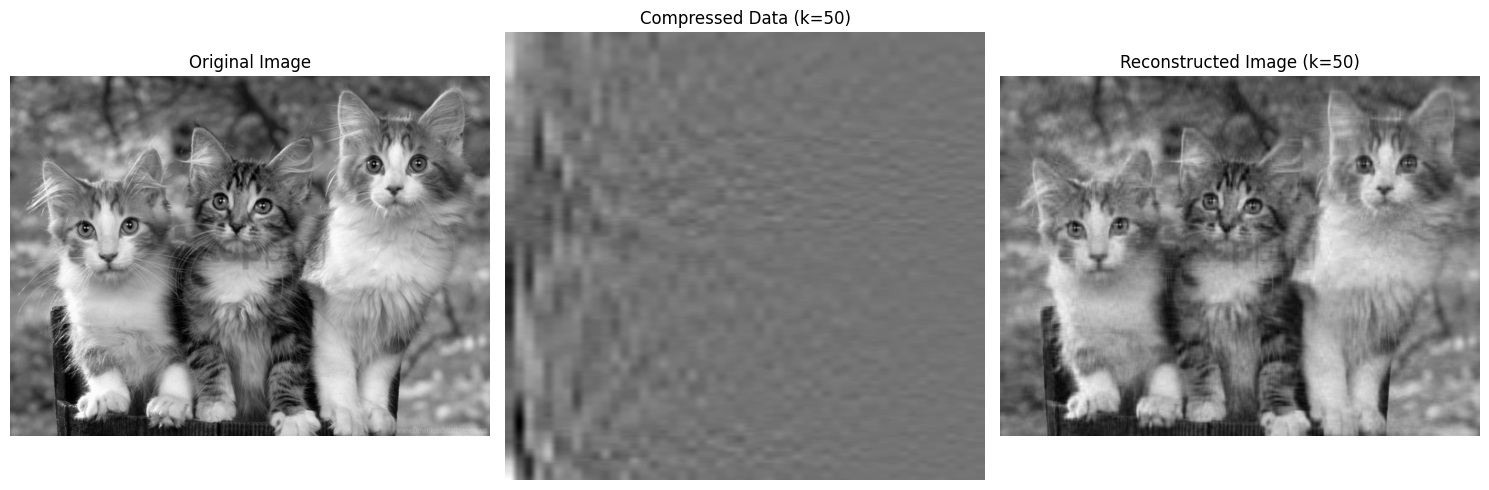

In [2]:
#task 3
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
img = np.array(Image.open("/content/drive/MyDrive/AI and ML/cats.jpg").convert('L'), dtype=np.float64)

h, w = img.shape
data = img.reshape(h, w)
mean = np.mean(data, axis=0)
centered_data = data - mean

cov_matrix = np.cov(centered_data, rowvar=False)

eig_values, eig_vectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eig_values)[::-1]
eig_vectors = eig_vectors[:, idx]
eig_values = eig_values[idx]

k = 50
components = eig_vectors[:, :k]

compressed_data = np.dot(centered_data, components)
print("Shape of compressed data:", compressed_data.shape)

decompressed_data = np.dot(compressed_data, components.T) + mean
print("Shape of decompressed data:", decompressed_data.shape)

plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1,3,2)
plt.imshow(compressed_data, cmap="gray", aspect='auto')
plt.title(f"Compressed Data (k={k})")
plt.axis("off")

# Reconstructed Image
plt.subplot(1,3,3)
plt.imshow(decompressed_data, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

plt.tight_layout()
plt.show()